# Multi-Head Attention and the Transformer Block

## Why Multiple Heads?

Single-head attention computes one set of Q, K, V projections and one attention pattern. But a single attention head can only "focus" on one kind of relationship at a time.

Consider the sentence: *"The animal didn't cross the street because it was too tired."*

When processing the word "it", a model needs to simultaneously reason about:
- **Syntactic relationship:** "it" is the subject of "was tired"
- **Coreference:** "it" refers to "animal", not "street"
- **Semantic context:** tiredness is an animal property, not a street property

A single attention head can capture one of these. **Multi-Head Attention (MHA)** runs `h` independent attention computations in parallel, each with its own learned projections. Each head can specialize and learn different aspects of the relationships between tokens. The outputs of all heads are then concatenated and linearly projected back to the original dimension.

```
Multi-Head(Q, K, V) = Concat(head_1, ..., head_h) W_O

where head_i = Attention(Q W_Q^i, K W_K^i, V W_V^i)
```

The total computation cost stays the same because each head uses a smaller dimension: `d_k = d_model / h`. If `d_model=512` and `h=8`, each head works in 64 dimensions instead of 512.

---

## Building Multi-Head Attention from Scratch

The tricky part is efficiently batching the heads together without writing a Python loop (which would be slow). The key trick is a **reshape + transpose** that stacks all heads into the batch dimension so a single `matmul` handles all of them simultaneously.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def scaled_dot_product_attention(Q, K, V, mask=None):
    """Single-head attention. Q/K/V: (batch, heads, seq, d_k)"""
    d_k    = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights


class MultiHeadAttention(nn.Module):
    """
    Multi-Head Self-Attention module.
    
    d_model: The full embedding dimension (e.g. 512)
    n_heads: Number of attention heads (e.g. 8)
    
    Each head works in dimension d_k = d_model // n_heads = 64.
    All heads run in parallel by reshaping tensors — no Python loop.
    """
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads  # Dimension per head
        
        # Four linear projections: Q, K, V each project from d_model → d_model
        # (internally split across n_heads), and W_O projects the concatenated output
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
    
    def forward(self, Q_in, K_in, V_in, mask=None):
        """
        Q_in, K_in, V_in: (batch, seq_len, d_model)
        
        In self-attention: Q_in == K_in == V_in (all same input)
        In cross-attention: Q_in comes from decoder, K_in/V_in from encoder
        """
        batch_size = Q_in.size(0)
        
        # Step 1: Linear projection. Shape after: (batch, seq, d_model)
        Q = self.W_q(Q_in)
        K = self.W_k(K_in)
        V = self.W_v(V_in)
        
        # Step 2: Reshape to split d_model into (n_heads, d_k)
        # Before: (batch, seq, d_model) = (batch, seq, n_heads * d_k)
        # After:  (batch, n_heads, seq, d_k)  — heads moved to dim 1
        # This is the key trick: we treat each head as part of the "batch"
        Q = Q.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        # Now shape is (batch, n_heads, seq_len, d_k)
        
        # Step 3: Apply attention to ALL heads simultaneously (efficient parallel computation)
        # attn_output shape: (batch, n_heads, seq, d_k)
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        
        # Step 4: Reassemble — undo the reshape, concatenate heads
        # transpose(1,2) → (batch, seq, n_heads, d_k)
        # contiguous() needed before view() because transpose creates non-contiguous memory
        # view(..., d_model) → (batch, seq, d_model)  — concatenates the heads
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(batch_size, -1, self.d_model)
        
        # Step 5: Final linear projection to mix information across heads
        output = self.W_o(attn_output)  # (batch, seq, d_model)
        
        return output, attn_weights


# --- Verify the shapes are correct ---
batch, seq, d_model, n_heads = 2, 10, 512, 8
mha = MultiHeadAttention(d_model, n_heads)

x = torch.randn(batch, seq, d_model)
output, weights = mha(x, x, x)  # Self-attention: Q=K=V=x

print(f"Input shape:   {x.shape}")
print(f"Output shape:  {output.shape}")   # (2, 10, 512) — same as input!
print(f"Weights shape: {weights.shape}")  # (2, 8, 10, 10) — 8 heads, 10×10 attn matrix

Input shape:   torch.Size([2, 10, 512])
Output shape:  torch.Size([2, 10, 512])
Weights shape: torch.Size([2, 8, 10, 10])


---

## The Transformer Encoder Block

A single Transformer encoder block has two sub-layers, each surrounded by a residual connection and a Layer Normalization:

1. **Multi-Head Self-Attention** — each token attends to all other tokens
2. **Feed-Forward Network (FFN)** — a 2-layer MLP applied independently to each token position

The residual connections serve the same purpose as in ResNet: they provide a direct gradient path and allow the network to be stacked many layers deep without vanishing gradients.

```
Output = LayerNorm(x + SubLayer(x))
```

**Why Layer Normalization instead of Batch Normalization?**
Batch Normalization normalizes across the batch dimension — it computes statistics from the current batch. But in NLP, sequences in a batch have different lengths and can contain wildly different types of content. Layer Normalization instead normalizes across the *feature* dimension for each individual token independently. This works better for variable-length sequences and is what's used throughout Transformers.

In [ ]:
class FeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network.
    Applied independently and identically to each token position.
    
    The inner dimension (d_ff) is typically 4× the model dimension.
    This large inner dimension is where the "memories" of transformer models live —
    research has shown that factual knowledge gets stored in FFN weights.
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),    # Project up (e.g. 512 → 2048)
            nn.GELU(),                   # GELU is standard in modern Transformers (smoother than ReLU)
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),    # Project back down (2048 → 512)
        )
    
    def forward(self, x):
        return self.net(x)  # (batch, seq, d_model) → (batch, seq, d_model)


class EncoderBlock(nn.Module):
    """
    One full Transformer Encoder layer.
    
    Structure:
        x → [MHA] → Add & LayerNorm → [FFN] → Add & LayerNorm → output
    
    The "Add" refers to the residual connection: output = x + SubLayer(x)
    The "Norm" is Layer Normalization applied after the addition.
    (Some modern variants use Pre-LN: LayerNorm before the sub-layer instead)
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ff        = FeedForward(d_model, d_ff, dropout)
        
        # Two separate LayerNorms: one after attention, one after FFN
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        # Sub-layer 1: Multi-Head Self-Attention with residual connection
        attn_output, _ = self.self_attn(x, x, x, mask)   # Self-attention: Q=K=V=x
        x = self.norm1(x + self.drop(attn_output))        # Residual + LayerNorm
        
        # Sub-layer 2: Feed-Forward Network with residual connection
        ff_output = self.ff(x)
        x = self.norm2(x + self.drop(ff_output))          # Residual + LayerNorm
        
        return x


# A full encoder: stack N encoder blocks
class TransformerEncoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)  # Final normalization
    
    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)


# BERT-base settings: 12 layers, 12 heads, d_model=768
encoder = TransformerEncoder(d_model=768, n_heads=12, d_ff=3072, n_layers=12)

x = torch.randn(2, 20, 768)  # Batch of 2, sequence of 20 tokens, 768-dim embeddings
output = encoder(x)
print(f"Encoder input:  {x.shape}")
print(f"Encoder output: {output.shape}")  # Same shape! (2, 20, 768)

total_params = sum(p.numel() for p in encoder.parameters())
print(f"Encoder parameters: {total_params:,}")  # ~85M for BERT-base

---

## Positional Encoding: Injecting Order

Here's a critical limitation of the Transformer: **it has no inherent notion of order**. If you shuffle the tokens randomly, the self-attention operation computes the exact same thing (it's a set operation, not a sequence operation). The `W_Q`, `W_K`, `W_V` projections treat each token identically regardless of its position.

We fix this by adding a **positional encoding** to each token's embedding before it enters the Transformer. The original "Attention Is All You Need" paper used sinusoidal functions of different frequencies. Modern models often learn positional embeddings from scratch (just like word embeddings).

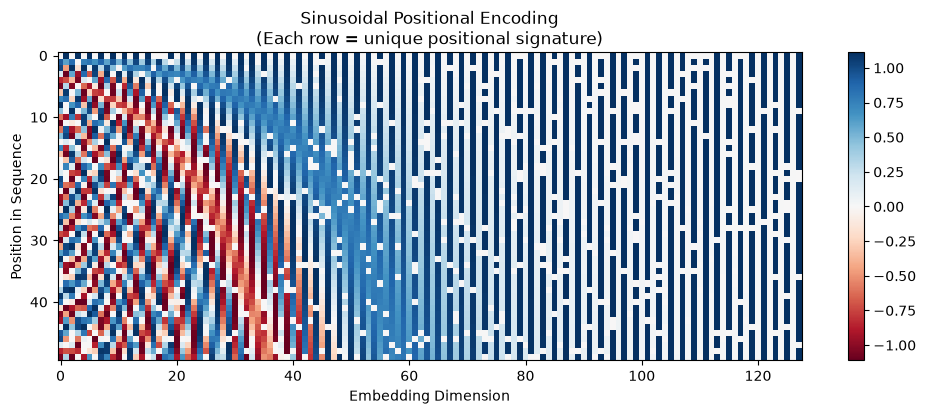

In [3]:
import math

class SinusoidalPositionalEncoding(nn.Module):
    """
    Adds a fixed position-dependent signal to each token embedding.
    
    For position pos and dimension i:
      PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
      PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    
    Different dimensions oscillate at different frequencies.
    Low dimensions: high frequency (changes every token)
    High dimensions: low frequency (changes every thousands of tokens)
    Together, each position gets a unique fingerprint.
    """
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        
        # Pre-compute the positional encoding matrix once
        pe = torch.zeros(max_len, d_model)
        positions = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)
        
        # The divisor term: 10000^(2i/d_model)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        
        pe[:, 0::2] = torch.sin(positions * div_term)  # Even dimensions: sin
        pe[:, 1::2] = torch.cos(positions * div_term)  # Odd dimensions: cos
        
        # Store as buffer: not a model parameter (not trained), but saved with the model
        pe = pe.unsqueeze(0)  # (1, max_len, d_model) — broadcast over batch
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        # Add the positional encoding for the first seq_len positions
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# Visualize: see how each position gets a unique pattern
pos_enc = SinusoidalPositionalEncoding(d_model=128)
dummy = torch.zeros(1, 50, 128)  # 50 tokens, 128-dim embeddings
encoded = pos_enc(dummy)

# Plot the positional encoding matrix (positions × dimensions)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.imshow(encoded[0].detach(), aspect='auto', cmap='RdBu')
plt.xlabel("Embedding Dimension")
plt.ylabel("Position in Sequence")
plt.title("Sinusoidal Positional Encoding\n(Each row = unique positional signature)")
plt.colorbar()
# plt.show()

---
## References
*   [Jay Alammar: The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)
*   [Vaswani et al. (2017): Attention Is All You Need](https://arxiv.org/abs/1706.03762)
*   [Andrej Karpathy: Let's build GPT from scratch](https://www.youtube.com/watch?v=kCc8FmEb1nY)